In [53]:
library(Seurat)
library(nicheDE)
library(qs)
library(glue)
library(ggplot2)
library(patchwork)
library(limma)
library(latex2exp)
library(ggtree)
library(paletteer)
library(scCustomize)
library(scico)
library(readxl)
library(ComplexHeatmap)
library(ggsci)
library(latex2exp)
library(ggrepel)
library(org.Hs.eg.db)
library(clusterProfiler)
library(RColorBrewer)
library(Polychrome)
library(stringr) 
library(tidytext)
library(parallel)
library(ggpubr)
library(dplyr)
library(tidyr)

Warning message:
“package ‘limma’ was built under R version 4.4.2”

Attaching package: ‘limma’


The following object is masked from ‘package:BiocGenerics’:

    plotMA




# 5C

In [10]:
spatialValuePlot <- function(df,
                             variable,
                             x_column="centroid_x",
                             y_column="centroid_y",
                             pt.size=0.2,
                             stroke=0.05,
                             ct.column="",
                             midpoint=NA,
                             plt.ct="",
                             title=variable,
                             palette=paletteer_c("viridis::inferno", n=30),
                             order=TRUE,
                             legend_title=variable,
                             custom_scale=FALSE,
                             scale_externel=NULL){
    mid_rescaler <- function(mid) {
      function(x, to = c(0, 1), from = range(x, na.rm = TRUE)) {
        scales::rescale_mid(x, to, from, mid)
      }
    }
    rescaler <- if (is.na(midpoint)) scales::rescale else mid_rescaler(midpoint)
    sp_aspect_ratio <- diff(range(df[, y_column]))/diff(range(df[, x_column]))
    if(nchar(plt.ct) > 0 & nchar(ct.column) > 0){
        df <- df %>%
        filter(!!sym(ct.column)==plt.ct)
    }
    if(order){
        df <- df %>%
        arrange(!!sym(variable))
    }
    color_bar <- if(custom_scale){scale_externel}else{scale_fill_gradientn(colors=palette, rescale=rescaler)}
    scale_bar_x_start <- min(df[, x_column, drop=TRUE]) + 50
    scale_bar_x_end <- min(df[, x_column, drop=TRUE]) + 50 + 1000
    scale_bar_y_pos <- min(df[, y_column, drop=TRUE] + 50)
    ggplot(df, aes(!!sym(x_column), !!sym(y_column), fill=!!sym(variable))) +
    geom_point(stroke=stroke, size=pt.size, shape=21) +
    theme_bw() +
    theme(aspect.ratio=sp_aspect_ratio,
          legend.key.size=unit(0.2, "cm"),
          legend.title=element_text(size=8, face="bold"),
          legend.text=element_text(size=5),
          panel.grid = element_blank(),
          axis.text=element_blank(),
          axis.ticks=element_blank(),
          plot.title=element_text(size=8, face="bold")) +
    color_bar +
    labs(x="sp1",
         y="sp2",
         fill=legend_title) +
    ggtitle(title) +
    annotate("segment",
             x=scale_bar_x_start,
             xend=scale_bar_x_end,
             y=scale_bar_y_pos,
             yend=scale_bar_y_pos,
             linewidth=0.5) +
    annotate("text",
             x=(scale_bar_x_start+scale_bar_x_end)/2,
             y=scale_bar_y_pos,
             label=paste0(1, " mm"),
             vjust=1.5,
             size=1.5)
}
getWeightedModuleScore <- function(features,
                                   feature_weights,
                                   seurat_obj,
                                   module_name,
                                   assay="Xenium"){
    assay.data <- GetAssayData(seurat_obj, assay=assay, layer="data")
    data.avg <- rowMeans(assay.data)
    data.avg <- data.avg[order(data.avg)]
    data.cut <- ggplot2::cut_number(x=data.avg+rnorm(n=length(data.avg))/1e+30,
                                    n=24,
                                    labels=FALSE,
                                    right=FALSE)
    names(data.cut) <- names(data.avg)
    names(feature_weights) <- features
    feature_gene_bins <- data.cut[features]
    unlist(lapply(feature_gene_bins, function(bin){
        names(sample(data.cut[data.cut==bin], size=20, replace=FALSE))
    })) -> ctrl.genes
    ctrl.genes.weights <- rep(feature_weights, each=20)
    dup_tbl <- tapply(ctrl.genes.weights, ctrl.genes, sum)
    ctrl.genes <- names(dup_tbl)
    ctrl.genes.weights <- as.numeric(dup_tbl)
    feature_scores <- as.numeric(Matrix::crossprod(assay.data[features, ], matrix(feature_weights, nrow=length(feature_weights))))/sum(abs(feature_weights))
    ctrl_scores <- as.numeric(Matrix::crossprod(assay.data[ctrl.genes, ], matrix(ctrl.genes.weights, nrow=length(ctrl.genes.weights))))/sum(abs(ctrl.genes.weights))
    module_score <- feature_scores - ctrl_scores
    module_score <- data.frame(module_score)
    colnames(module_score) <- module_name
    rownames(module_score) <- colnames(assay.data)
    return(module_score)
                                   }

In [5]:
all_ra_samples <- list.dirs("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/", recursive=FALSE, full.names=TRUE)
all_sample_ids <- str_extract(all_ra_samples, "RA\\d+[A-Z]*")
height_width_param <- c("6&8", "6.5&7", "6&8", "5&9", "6&8", "7.5&4", "6&10", "6&10", "8&10", "6&8")
names(height_width_param) <- c("RA401", "RA331", "RA442", "RA443", "RA457", "RA480", "RA494", "RA519", "RA362", "RA489")
kmeans_res <- qread("/data1/deyk/harry/RA_Xenium/results/nicheassay/kmeans_res/k_5_res.qs")
kmeans_res <- kmeans_res$cluster
kmeans_niche_df <- data.frame(Niche=kmeans_res) %>%
    mutate(sample=gsub("_.+", "", names(kmeans_res)))
kmeans_niche_df <- split(kmeans_niche_df, kmeans_niche_df$sample)
kmeans_niche_df <- lapply(kmeans_niche_df, function(df){
    rownames(df) <- gsub("RA[0-9]+_", "", rownames(df))
    df %>% 
    mutate(Niche=factor(Niche))
})
all_xenium_samples <- lapply(all_sample_ids, function(sample){
    qread(glue("/data1/deyk/harry/RA_Xenium/data/post_qc_data_baysor/{sample}/final_version_seurat_obj.qs"))
})
all_xenium_samples <- lapply(all_xenium_samples, function(obj){
    # discard assays we don't need, merging will be faster this way
    DefaultAssay(obj) <- "Xenium"
    obj[["SCT"]] <- NULL
    obj[["ControlCodeword"]] <- NULL
    obj[["ControlProbe"]] <- NULL
    coords <- GetTissueCoordinates(obj) %>%
        tibble::column_to_rownames("cell")
    obj@images <- list()
    obj <- AddMetaData(obj, coords)
    return(obj)
})
all_xenium_samples <- setNames(all_xenium_samples, all_sample_ids)
all_xenium_samples <- lapply(names(all_xenium_samples), function(sample){
    AddMetaData(all_xenium_samples[[sample]], kmeans_niche_df[[sample]])
})
all_xenium_merged <- merge(all_xenium_samples[[1]], all_xenium_samples[-1])
all_xenium_merged[["Xenium"]] <- JoinLayers(all_xenium_merged[["Xenium"]])
all_xenium_merged <- NormalizeData(all_xenium_merged, normalization.method="LogNormalize")

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Normalizing layer: counts



In [7]:
all_module_wgcna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/Merged_WGCNA_gene_kME.csv")

In [8]:
module_list_Ian_spatial_wgcna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/spatialmodules101625.csv")
module_list_Ian_spatial_wgcna %>% filter(Gene %in% rownames(all_xenium_merged)) -> module_list_Ian_spatial_wgcna 
module_list_Ian_spatial_wgcna <- split(module_list_Ian_spatial_wgcna, module_list_Ian_spatial_wgcna$Title)
module_list_Ian_spatial_wgcna <- lapply(module_list_Ian_spatial_wgcna, function(module_df){
    setNames(module_df$Weight, module_df$Gene)
})

In [14]:
module_scores_wgcna_2 <- getWeightedModuleScore(names(module_list_Ian_spatial_wgcna[["ME1_pkME"]]),
                           unname(module_list_Ian_spatial_wgcna[["ME1_pkME"]]),
                           all_xenium_merged,
                           "ME1_pkME")

In [17]:
plt_data_module <- cbind(all_xenium_merged@meta.data, module_scores_wgcna_2[rownames(all_xenium_merged@meta.data), , drop=FALSE])

In [22]:
getSharedScales <- function(values,
                            midpoint){
    min_val <- min(values)
    max_val <- max(values)
    mid_rescaler <- function(mid) {
      function(x, to = c(0, 1), from = range(x, na.rm = TRUE)) {
        scales::rescale_mid(x, to = to, from = from, mid = mid)
      }
    }
    rescaler <- mid_rescaler(midpoint)
    shared_scales <- scale_fill_gradientn(colors=rev(paletteer::paletteer_c("ggthemes::Red-Blue Diverging", n = 100)),
                                          limits=c(min_val, max_val),
                                          rescaler=rescaler)
    return(shared_scales)
                            }
shared_scale <- getSharedScales(plt_data_module[["ME1_pkME"]], 0)
all_module_plt_5c <- lapply(all_sample_ids, function(sample_id){
    figure_height_width <- as.numeric(str_split(height_width_param[sample_id], "&")[[1]])
  spatialValuePlot(plt_data_module %>% filter(sample==sample_id),
                         custom_scale=TRUE,
                         scale_externel=shared_scale,
                         pt.size=0.2,
                         stroke=0,
                         variable="ME1_pkME",
                         x_column="y",
                         y_column="x",
                         order=TRUE,
                         legend_title="ME1_pKME") -> plt.tmp
    ggsave(plot=plt.tmp,
           filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure5/5C_{sample_id}.png"),
           height=figure_height_width[1],
           width=figure_height_width[2],
           dpi=700,
           limitsize=FALSE
           )
})

# 5B

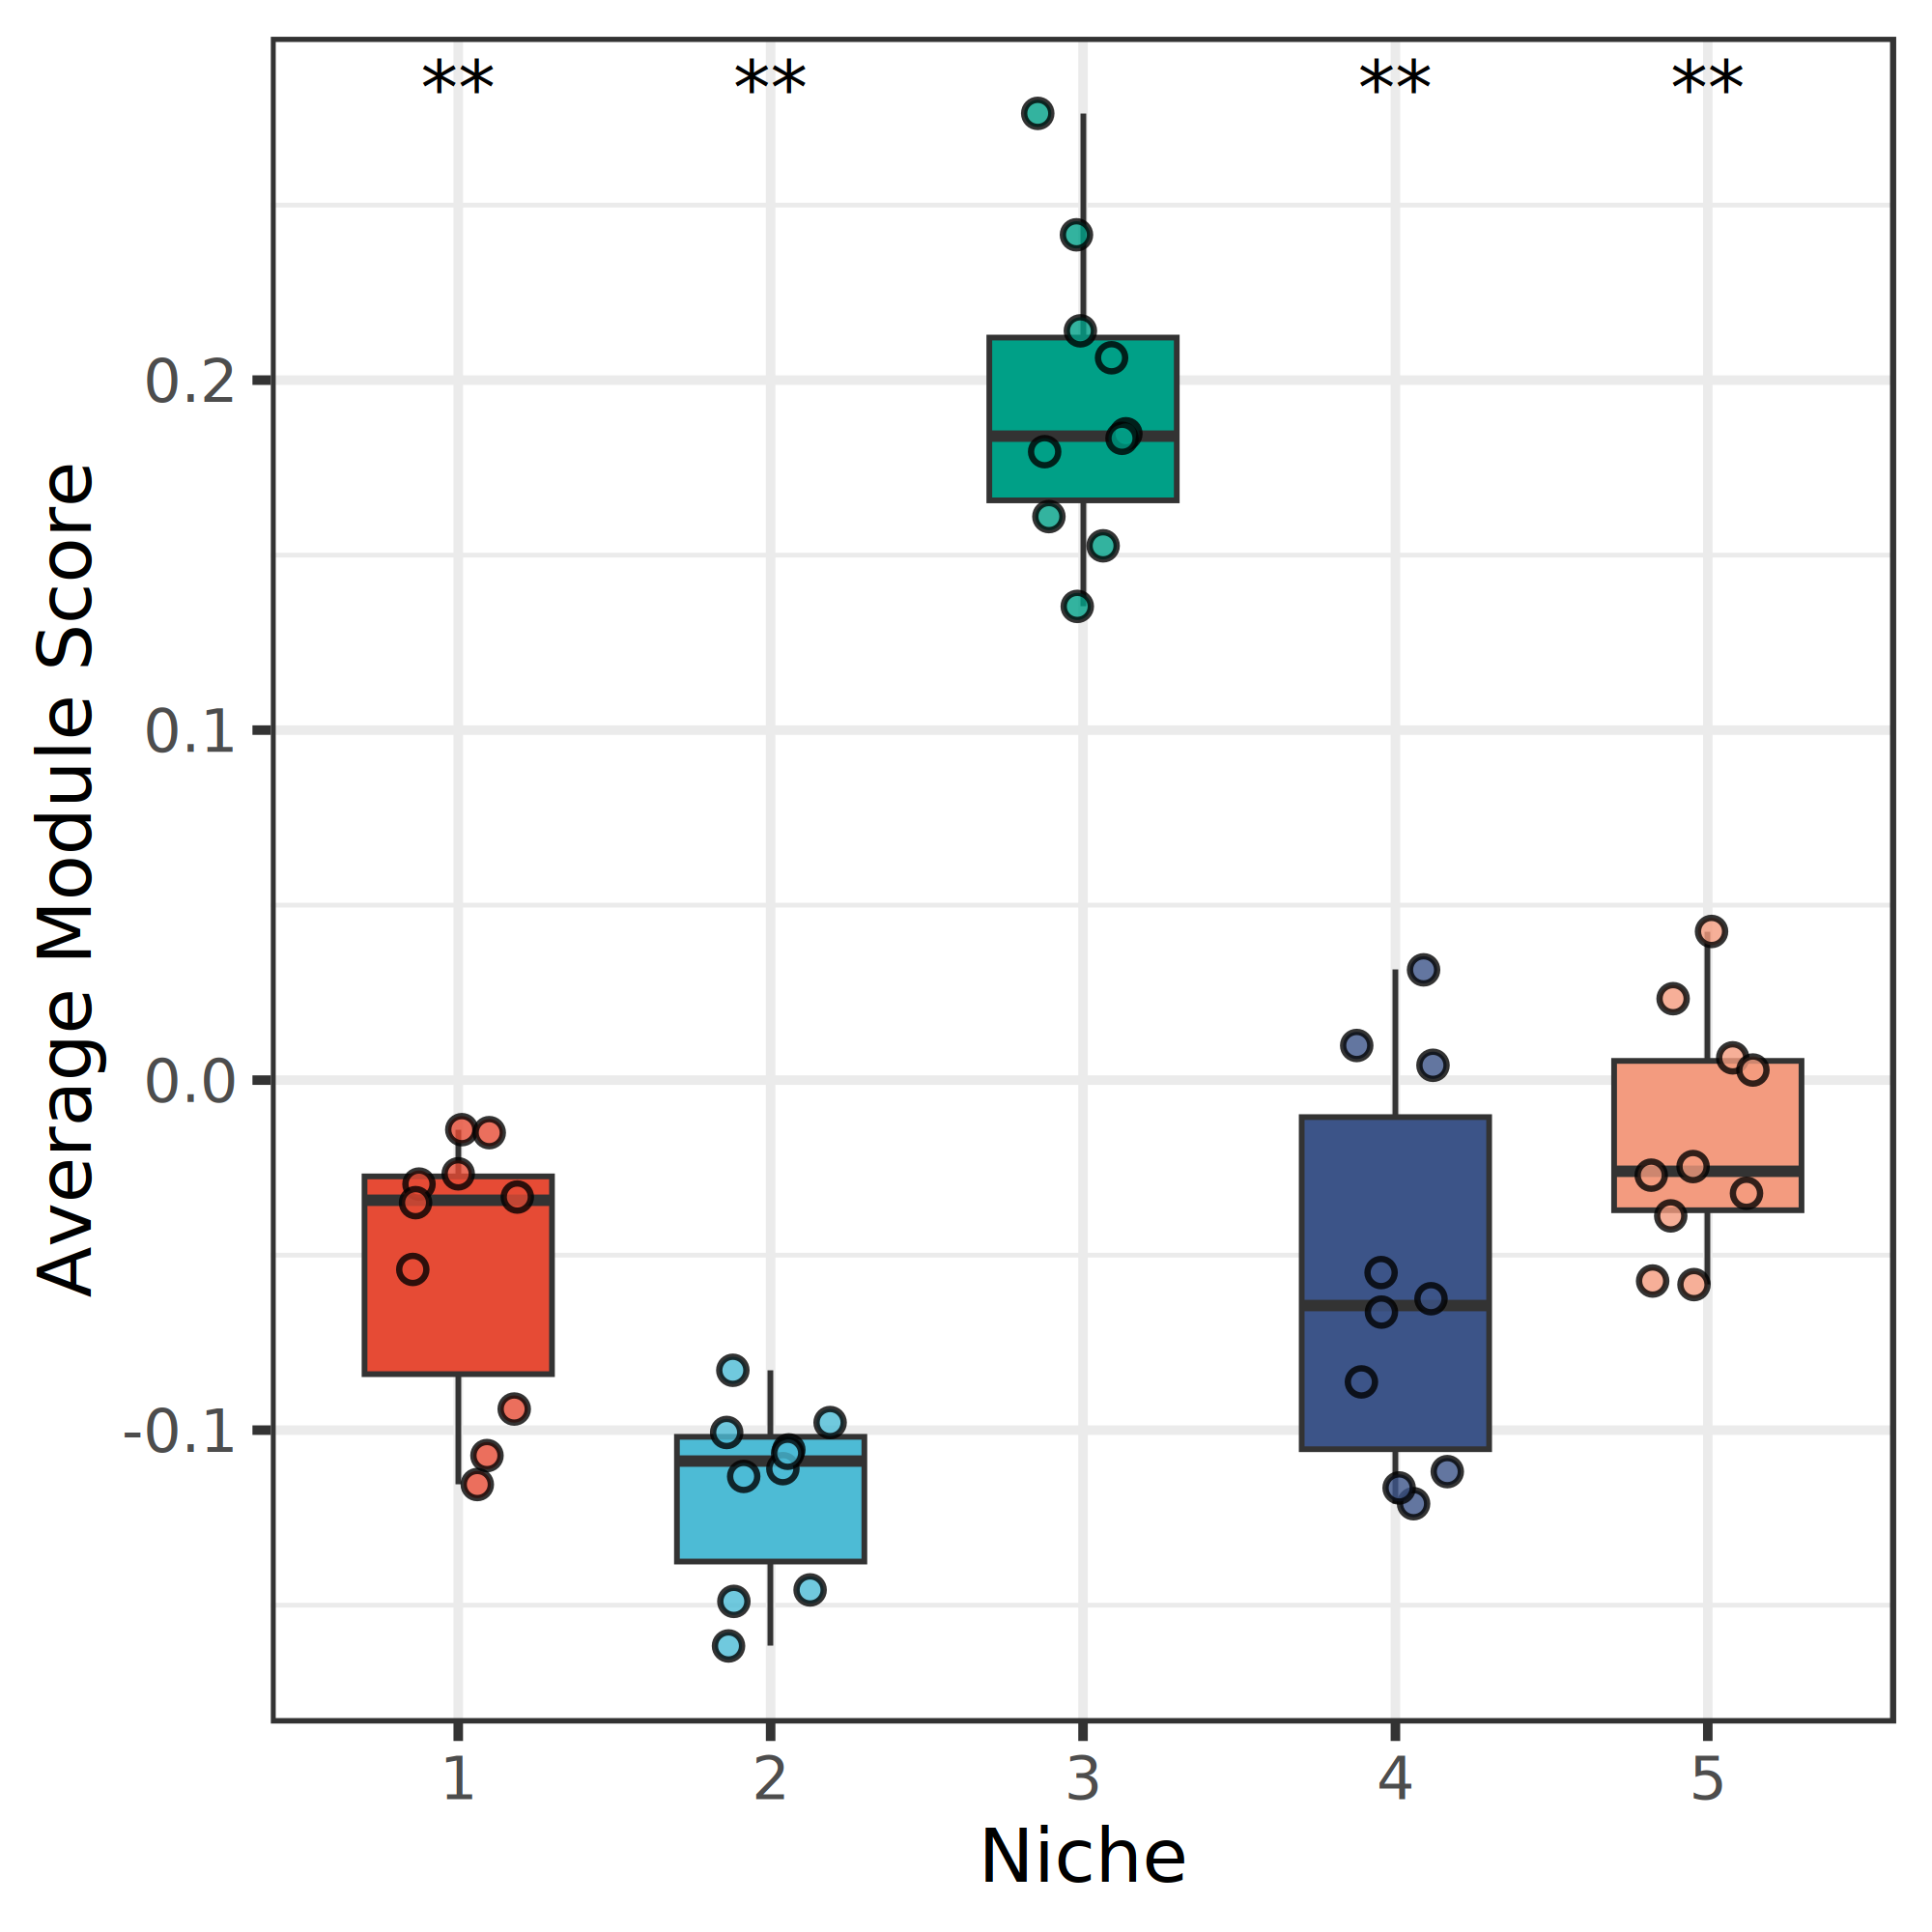

In [72]:
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 500)
plt_data_module %>%
  select(ME1_pkME, sample, Niche) %>%
  group_by(Niche, sample) %>%
  summarize(mean_score = mean(ME1_pkME, na.rm = TRUE), .groups = "drop") %>%
  ggplot(aes(x = Niche, y = mean_score)) +
  geom_boxplot(aes(fill = Niche),
               width = 0.6, outlier.shape = NA, linewidth = 0.3) +
  geom_point(aes(fill = Niche),
             colour="black",
             shape=21,
             position = position_jitter(width = 0.2, height = 0),
             size = 1.5, alpha = 0.8) +
  scale_fill_manual(values = niche_palette) + 
  stat_compare_means(
    ref.group = "3",
    paired = TRUE,
    label = "p.signif",
    method = "wilcox.test",
    method.args = list(alternative = "less")
  ) +
  theme_bw() +
  theme(legend.position="none") +
  labs(y="Average Module Score")
ggsave(filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure5/5B.png"),
       height=4,
       width=4,
       dpi=700
       )

# 5D

In [50]:
tcz_rna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/TCZ_data_DEG.csv") %>% tibble::column_to_rownames("gene_name")
rtx_rna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/RTX_data_DEG.csv") %>% tibble::column_to_rownames("gene_name")
merged_rna <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/Merged_data_DEG.csv") %>% tibble::column_to_rownames("gene_name")
patient_info <- read.csv("/data1/deyk/harry/RA_Xenium/data/bulk_R4RA/R4RA_phenotype.csv")

In [51]:
patient_info %>%
    mutate(treatment=ifelse(Timepoint==0, "C", "T"),
           treatment=factor(treatment, levels=c("C", "T"))) -> patient_info

In [52]:
patient_info %>%
    filter(Drug=="TOC" & Timepoint==0 & Pathotype=="Myeloid") %>%
    pull(Patient_ID) -> tcz_meyloid_0_sample_ids

In [54]:
patient_info %>%
    filter(Patient_ID %in% tcz_meyloid_0_sample_ids, Header %in% colnames(tcz_rna)) %>%
    group_by(Patient_ID) %>%
    mutate(n_sample=n()) %>%
    ungroup() %>%
    filter(n_sample==2) %>%
    tibble::column_to_rownames("Header") %>%
    mutate(patient_id=factor(Patient_ID)) -> tcz_patient_info_myeloid
design_tcz_16_v_0_myeloid <- model.matrix(~treatment + patient_id, data=tcz_patient_info_myeloid)
tcz_16_v_0_rna_myeloid <- tcz_rna[, rownames(design_tcz_16_v_0_myeloid)]

In [55]:
fit_tcz_16_v_0_rna_myeloid <- lmFit(tcz_16_v_0_rna_myeloid, design=design_tcz_16_v_0_myeloid)
fit_tcz_16_v_0_rna_myeloid <- eBayes(fit_tcz_16_v_0_rna_myeloid, trend=TRUE)
topTable(fit_tcz_16_v_0_rna_myeloid, coef = "treatmentT", number = Inf, adjust.method = "BH") %>%
    arrange(logFC) -> DEGs_all_tcz_16_v_0_meyloid

In [56]:
sc_ref <- qread("/data1/deyk/harry/RA_Xenium/data/Zhang_Nat_2023_AMP/AMP_PhaseII_seurat.qs")
metadata_all_sc_ref <- readRDS("/data1/deyk/harry/RA_Xenium/data/Zhang_Nat_2023_AMP/all_cells_reference.rds")

In [57]:
organizeDEGsList <- function(fc_cutoff,
                             pval_cutoff,
                             degs_list,
                             sc_ref){
    if(fc_cutoff < 0){
        degs.tmp <- degs_list %>%
            filter(logFC <= fc_cutoff & P.Value <= pval_cutoff)
    }else{
        degs.tmp <- degs_list %>%
            filter(logFC >= fc_cutoff & P.Value <= pval_cutoff)
    }
    degs.tmp <- degs.tmp %>%
        mutate(gene=rownames(.)) %>%
        filter(gene %in% rownames(sc_ref)) %>%
        arrange(desc(abs(logFC)))
    setNames(abs(degs.tmp$logFC), degs.tmp$gene)
                             }
module_tcz_16_v_0_meyloid <- organizeDEGsList(-0.5,
                                      0.01,
                                      DEGs_all_tcz_16_v_0_meyloid,
                                      sc_ref)

In [58]:
getWeightedModuleScorescRNA <- function(features,
                                   feature_weights,
                                   seurat_obj,
                                   module_name){
    assay.data <- GetAssayData(seurat_obj, assay="RNA", layer="data")
    data.avg <- rowMeans(assay.data)
    data.avg <- data.avg[order(data.avg)]
    data.cut <- ggplot2::cut_number(x=data.avg+rnorm(n=length(data.avg))/1e+30,
                                    n=24,
                                    labels=FALSE,
                                    right=FALSE)
    names(data.cut) <- names(data.avg)
    names(feature_weights) <- features
    feature_gene_bins <- data.cut[features]
    unlist(lapply(feature_gene_bins, function(bin){
        names(sample(data.cut[data.cut==bin], size=100, replace=FALSE))
    })) -> ctrl.genes
    ctrl.genes.weights <- rep(feature_weights, each=100)
    dup_tbl <- tapply(ctrl.genes.weights, ctrl.genes, sum)
    ctrl.genes <- names(dup_tbl)
    ctrl.genes.weights <- as.numeric(dup_tbl)
    feature_scores <- as.numeric(Matrix::crossprod(assay.data[features, ], matrix(feature_weights, nrow=length(feature_weights))))/sum(abs(feature_weights))
    ctrl_scores <- as.numeric(Matrix::crossprod(assay.data[ctrl.genes, ], matrix(ctrl.genes.weights, nrow=length(ctrl.genes.weights))))/sum(abs(ctrl.genes.weights))
    module_score <- feature_scores - ctrl_scores
    module_score <- data.frame(module_score)
    colnames(module_score) <- module_name
    rownames(module_score) <- colnames(assay.data)
    return(module_score)
                                   }

In [61]:
tcz_16_v_0_myeloid_module_scores <- getWeightedModuleScorescRNA(names(module_tcz_16_v_0_meyloid),
                           unname(module_tcz_16_v_0_meyloid),
                           sc_ref,
                           "TCZ_Myeloid_w16_v_w0")

In [63]:
umap_embeddings <- data.frame(metadata_all_sc_ref$umap$embedding)
rownames(umap_embeddings) <- metadata_all_sc_ref$meta_data$cell
umap_embeddings <- cbind(umap_embeddings, tcz_16_v_0_myeloid_module_scores[rownames(umap_embeddings), ,drop=FALSE])
umap_embeddings$ct <- sc_ref@meta.data[rownames(umap_embeddings), ]$cluster_name
umap_embeddings$broad_ct <- sc_ref@meta.data[rownames(umap_embeddings), ]$cell_type
umap_embeddings %>%
  mutate(ct=gsub(":.+", "", as.character(ct)),
         ct=gsub(" .+", "", ct)) -> umap_embeddings

In [ ]:
mac_superset_cluster_pal <- brewer.pal("Set3", n=5)
mac_superset_cluster_pal <- mac_superset_cluster_pal[-2]
names(mac_superset_cluster_pal) <- c("DC", "Monocytes", "SPP1hi", "Tissue")

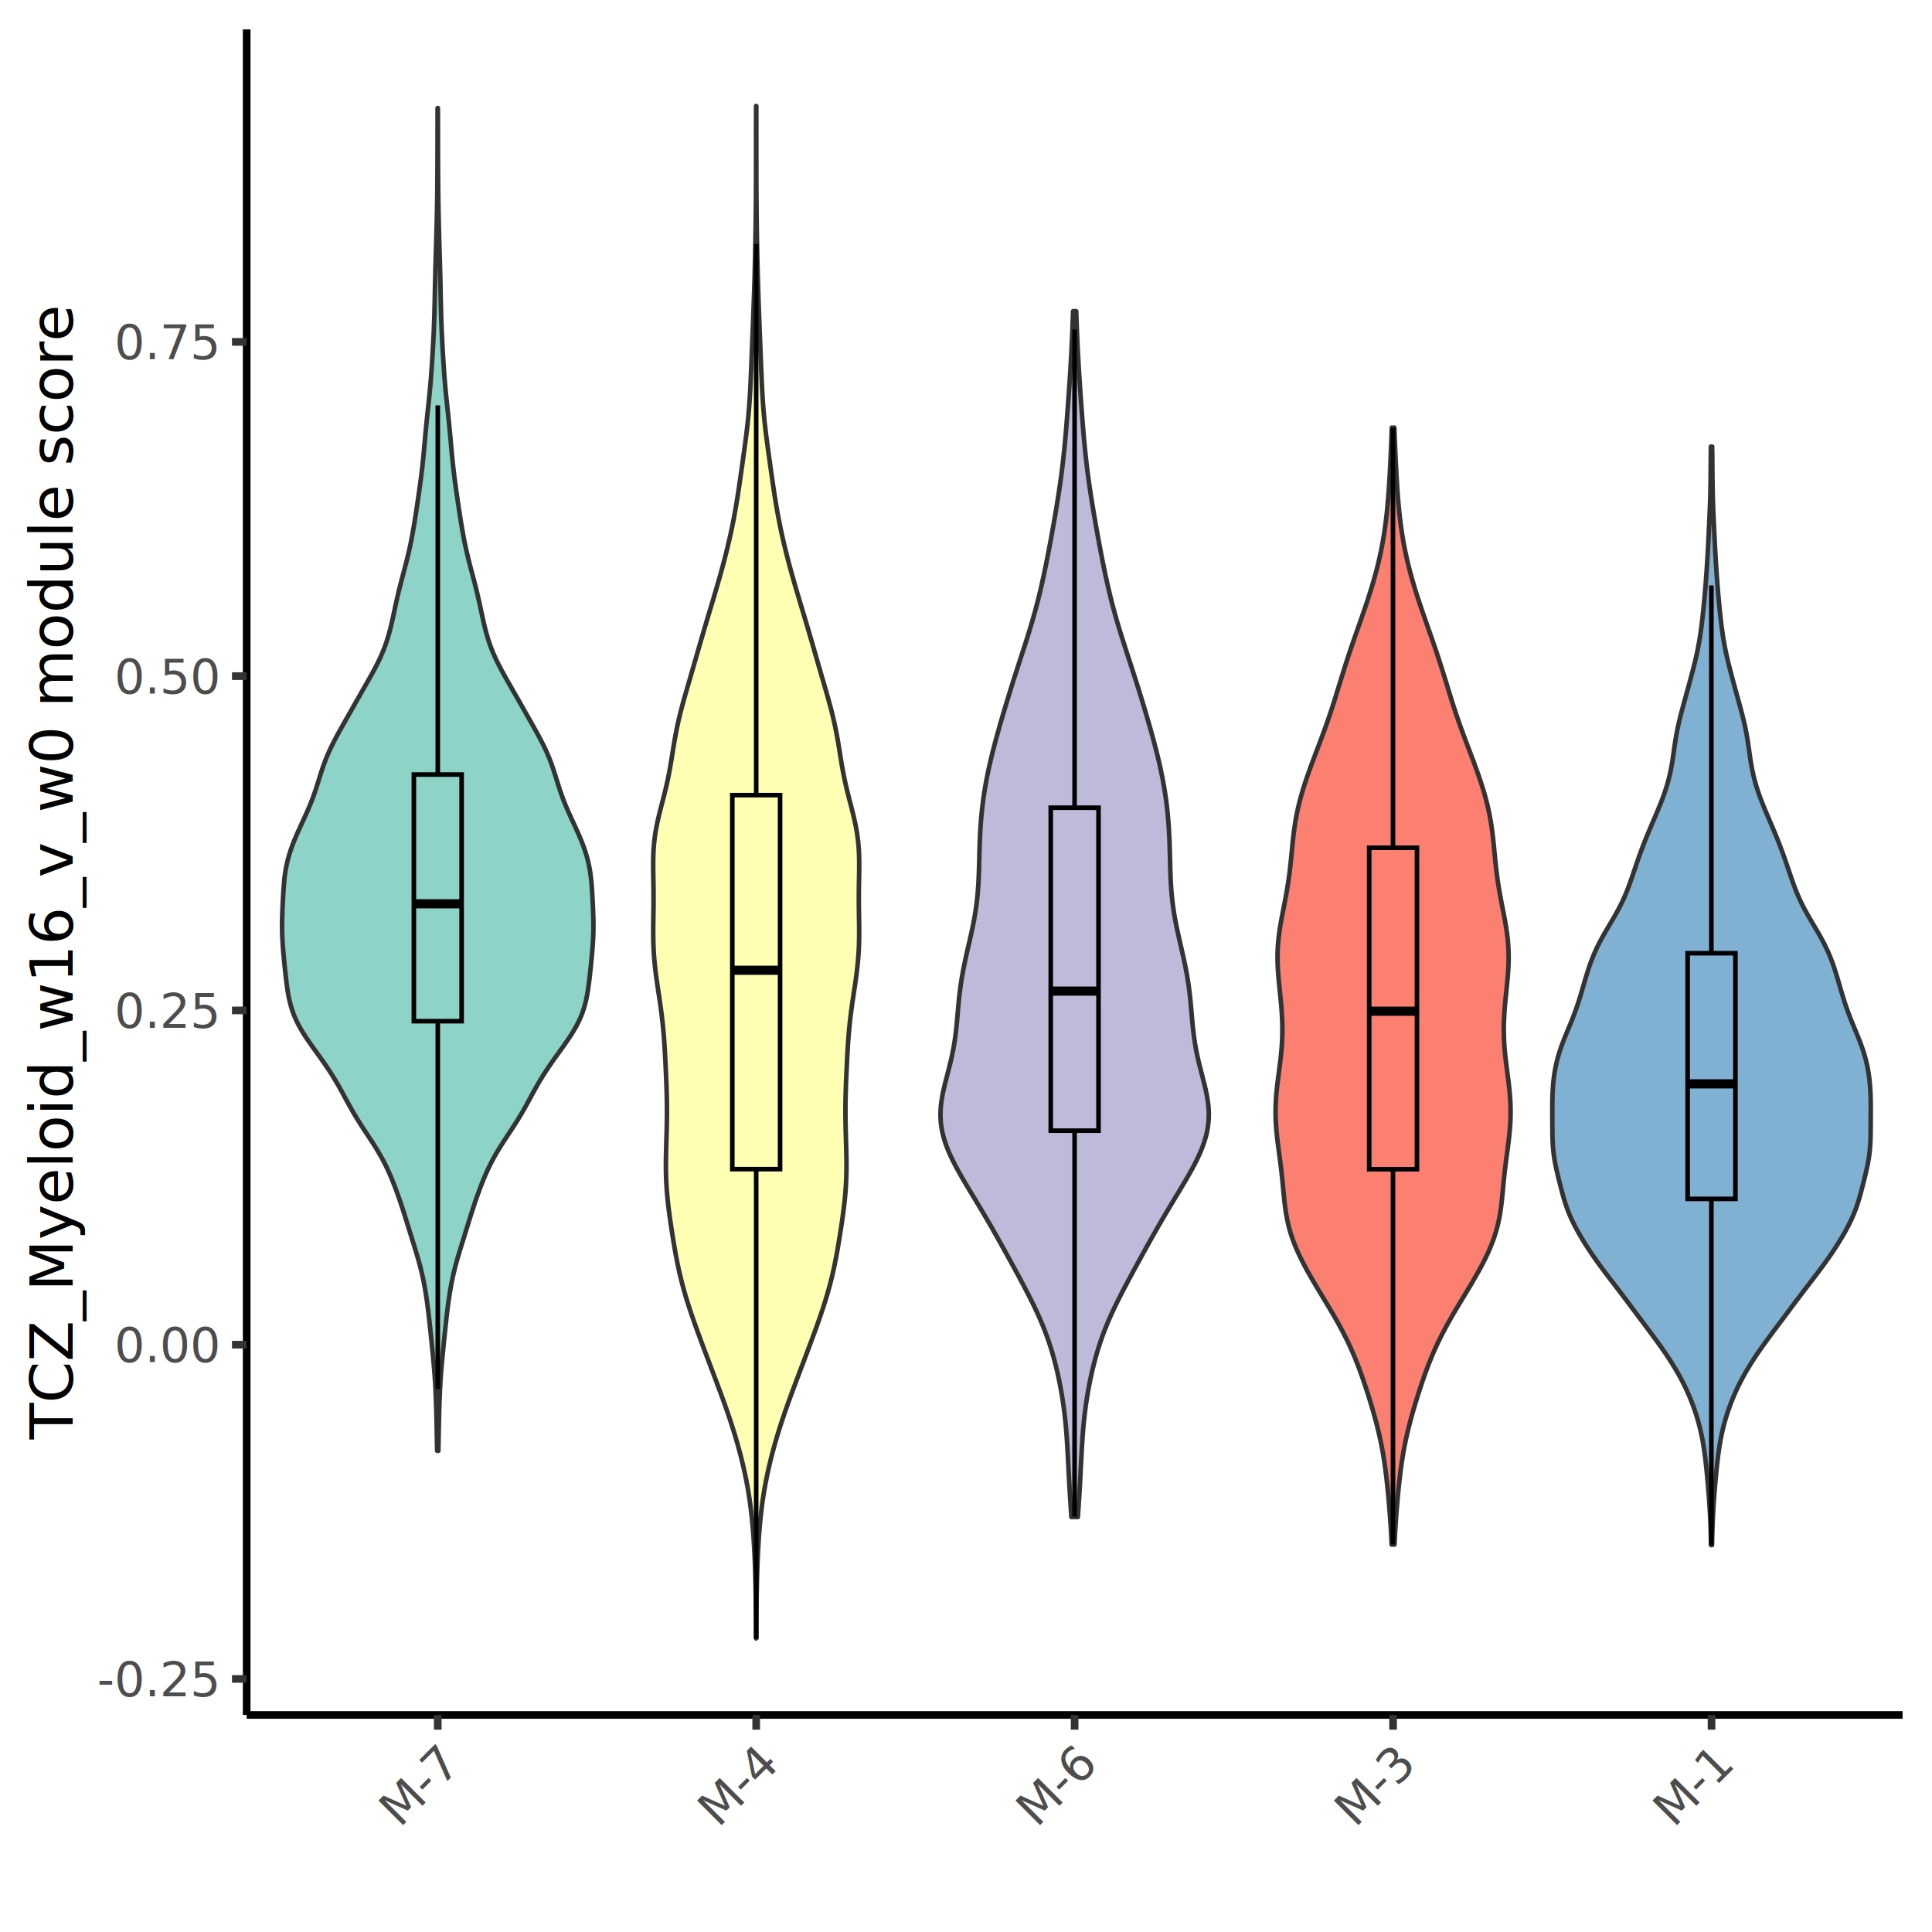

In [69]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 500)
umap_embeddings %>%
        mutate(ct = reorder(ct,TCZ_Myeloid_w16_v_w0, FUN = median, decreasing = TRUE)) -> plt.df.module.myeloid.tcz
top_cts <- levels(plt.df.module.myeloid.tcz$ct)[1:5]
plt.df.module.myeloid.tcz[["TCZ_Myeloid_w16_v_w0"]] <- plt.df.module.myeloid.tcz[["TCZ_Myeloid_w16_v_w0"]] + rnorm(mean=0, sd=1e-8, n=nrow(plt.df.module.myeloid.tcz))
ggplot(plt.df.module.myeloid.tcz %>% filter(ct %in% top_cts), aes(x = ct, y = TCZ_Myeloid_w16_v_w0, fill=ct)) +
    geom_violin(trim = TRUE, width=1, linewidth=0.3) +
    geom_boxplot(width = 0.15, color = "black", outliers=FALSE, linewidth=0.3) +
    theme_classic() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none") +
    xlab("") +
    ylab("TCZ_Myeloid_w16_v_w0 module score") +
    scale_fill_manual(values=brewer.pal("Set3", n=5))
ggsave(filename=glue("/data1/deyk/harry/RA_Xenium/results/figures/manuscript_final_version_figures/figure5/5D.png"),
       height=5,
       width=5,
       dpi=700
       )